# Preprocessing — Putting Features on a Common Footing

Almost no dataset arrives in a state a model can use. Columns are measured in wildly different
units, some are text rather than numbers, and some carry information that is easier to use in a
different form. **Preprocessing** is the step that fixes this, and it is not cosmetic: the previous
section showed cosine similarity return a meaningless answer on raw features and a useful one after
scaling. Same data, same metric — the preprocessing decided whether it worked.

This notebook is a tour of the `sklearn.preprocessing` tools, split into the numerical case and the
categorical case. Throughout we watch two things after every transform: the **summary statistics**
and the **correlation** between the two features. Which of those a transform preserves, and which it
deliberately destroys, is the clearest way to see what each one actually does.

## Learning objectives

- Standardize features to z-scores with `StandardScaler` and say what it guarantees
- Rescale features to a fixed range with `MinMaxScaler`, and explain its sensitivity to outliers
- Use `PCA` to rotate correlated features into uncorrelated components
- Threshold a continuous feature into a binary one with `Binarizer`
- Encode categorical text with `LabelEncoder` and `OneHotEncoder`, and choose correctly between them
- Explain why a scaler must be fit on training data only

## Background

This notebook assumes the mean, standard deviation, and correlation of a column, and takes for
granted that features on different scales cause trouble — a claim demonstrated concretely in
`U1-1_Embeddings-1_Tabular`, where unscaled features made every pair of homes look identical.

Each transform's formula is given in the section that applies it.

## This notebook covers

1. Numerical data — standardizing, rescaling, rotating, and thresholding
2. Categorical data — label encoding and one-hot encoding

**Prerequisites:** `U1-1_Embeddings-1_Tabular` (why unscaled features break distance measures)

**Dataset:** none — two correlated Gaussian features generated in section 1, and a four-element
array of animal names in section 2.

**References:** https://scikit-learn.org/stable/modules/classes.html#module-sklearn.preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Preprocessing numerical data

### 1.1 Create the data

Two features built to be **correlated on purpose**: $a \sim \mathcal{N}(1,\ 0.5^2)$, and
$b \sim \mathcal{N}(-1,\ 0.25^2) + 1.5\,a$. Because $b$ is built from $a$, the two rise together,
and the scatter below is a tilted cloud rather than a round one.

They also have different means and different spreads, which is what the scalers in the next two
sections address.

In [2]:
nPts= 1000

a = np.random.normal( 1, 0.5, nPts)
b = np.random.normal(-1, 0.25, nPts) + a*1.5
X = np.array([a,b]).T

df_X = pd.DataFrame(X)
df_X

,0,1
0,0.404215,-0.296030
1,1.104816,0.542866
2,1.234755,0.883702
3,0.943247,0.278187
4,0.686608,0.242306
...,...,...
995,0.699086,0.005810
996,0.365637,-0.297703
997,1.252604,0.469256
998,0.554185,0.096622


Every plot in this notebook uses the same axis limits and `set_aspect('equal')`, so the cloud's
size, position, and shape can be compared honestly from section to section. Watch three things in
each `describe()` / `corr()` pair: where the cloud sits (`mean`), how big it is (`std`), and whether
the two features still move together (`corr`).

,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.004958,0.498776,-0.627023,0.67815,0.984094,1.331267,2.843643
1,1000.0,0.507821,0.792709,-2.195307,0.00676,0.480744,1.031826,3.444627


,0,1
0,1.000000,0.951118
1,0.951118,1.000000


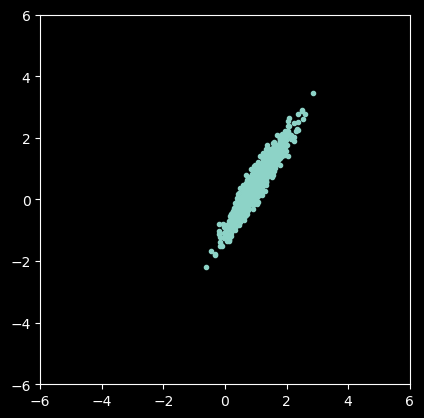

In [3]:
display(df_X.describe().T)
display(df_X.corr())

plt.plot( X[:,0], X[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### 1.2 Standard scaler — convert to z-scores

`StandardScaler` replaces each value with the number of standard deviations it sits from its
column's mean:

$$z = \frac{x - \mu}{\sigma}$$

Every column comes out with mean 0 and standard deviation 1, which is what the `describe()` output
below should confirm. This is the default choice for models that compare features against each
other — KNN, SVMs, linear models with regularization, and neural networks all assume roughly
comparable feature scales.

Note what does **not** change: the correlation. Subtracting a constant and dividing by a constant
is an affine map applied per column, and correlation is invariant to that. The cloud moves to the
origin and changes size, but its tilt survives.

> **The rule that matters in practice:** call `fit` on the training data only, then `transform`
> both splits with that same fitted scaler. Fitting on everything lets the test set's mean and
> standard deviation leak into training and quietly inflates your scores. Here there is no split,
> so `fit_transform` on the whole array is fine.

,count,mean,std,min,25%,50%,75%,max
0,1000.0,-1.421085e-16,1.0005,-3.273609,-0.655548,-0.041851,0.654546,3.688239
1,1000.0,-2.131628e-17,1.0005,-3.411694,-0.632402,-0.034174,0.661362,3.706626


,0,1
0,1.000000,0.951118
1,0.951118,1.000000


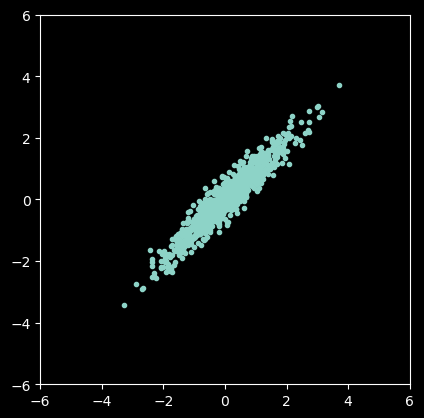

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1 = scaler.fit_transform(X)

df_X1 = pd.DataFrame(X1)
display(df_X1.describe().T)
display(df_X1.corr())

plt.plot( X1[:,0], X1[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### 1.3 Min-max scaler — rescale to a fixed range

`MinMaxScaler` maps each column onto $[0, 1]$ by anchoring its smallest and largest values:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

The red square drawn on the plot is the unit box every point is now inside. Use this when a bounded
range is required — image pixels, or an activation expecting inputs in $[0,1]$.

Its weakness follows directly from the formula: only two values, the min and the max, determine the
transform. **One outlier compresses everything else into a sliver of the range.** `StandardScaler`
uses the mean and standard deviation, which every point contributes to, and is far steadier in the
presence of outliers.

Correlation again survives, for the same reason as before.

,count,mean,std,min,25%,50%,75%,max
0,1000.0,0.470221,0.143712,0.0,0.376058,0.464210,0.564240,1.0
1,1000.0,0.479284,0.140553,0.0,0.390442,0.474483,0.572193,1.0


,0,1
0,1.000000,0.951118
1,0.951118,1.000000


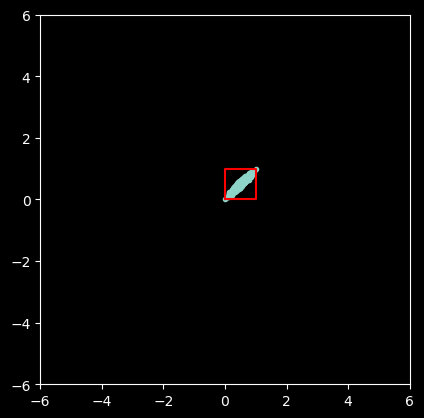

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X2 = scaler.fit_transform(X)

df_X2 = pd.DataFrame(X2)
display(df_X2.describe().T)
display(df_X2.corr())

plt.plot( X2[:,0], X2[:,1], '.' )
plt.plot( [0,1,1,0,0], [0,0,1,1,0], 'r' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### 1.4 PCA — rotate into uncorrelated components

The three transforms so far worked one column at a time and left the tilt of the cloud alone.
**Principal component analysis** does the opposite: it acts on the features jointly and removes the
tilt entirely.

PCA takes the covariance matrix of the centered data,

$$\Sigma = \frac{1}{n}\sum_{i=1}^{n} (\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^{\top}$$

computes its eigenvectors, and uses them as a new set of axes. The first points along the direction
of greatest variance, the second along the greatest variance perpendicular to it, and so on.
Projecting onto those axes,

$$\mathbf{z} = W^{\top}(\mathbf{x} - \bar{\mathbf{x}})$$

gives components whose covariance matrix is **diagonal** — every off-diagonal entry is zero.

So this is the first transform where the correlation output should change: expect essentially 0
off the diagonal. Watch the scatter too — the cloud is the same cloud, rotated so its long axis
lies along the horizontal.

PCA is run here on the already-standardized `X1`, not the raw `X`. That ordering matters, and for
the same reason the whole notebook exists: PCA maximizes variance, so an unscaled column with a
large numeric range would dominate the first component through its units alone.

,count,mean,std,min,25%,50%,75%,max
0,1000.0,1.421085e-17,1.397523,-4.727222,-0.905658,-0.064448,0.945745,5.228959
1,1000.0,3.330669e-18,0.221203,-0.650551,-0.143844,-0.008006,0.151811,0.722146


,0,1
0,1.000000e+00,3.602157e-16
1,3.602157e-16,1.000000e+00


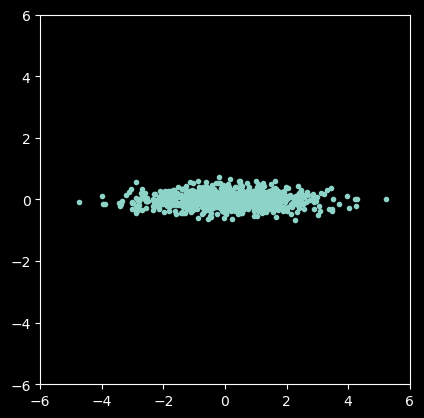

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X3 = pca.fit_transform(X1) # run PCA after std scale

df_X3 = pd.DataFrame(X3)
display(df_X3.describe().T)
display(df_X3.corr())

plt.plot( X3[:,0], X3[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### 1.5 Binarizer — threshold into 0/1

The bluntest transform: everything above a threshold becomes 1, everything else 0.

$$x' = \begin{cases} 1 & x > t \\ 0 & x \le t \end{cases}$$

This throws away nearly all the information in a feature, which is occasionally the right call —
when only "high versus low" matters, or when a model needs binary input. Note that it is applied to
`X2`, the min-max output, so the threshold of 0.5 means "upper half of the observed range."
Thresholds are only meaningful relative to the scale they act on.

In [7]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold=0.5)

X4 = binarizer.fit_transform(X2)

print(X2[:4,:])
print(X4[:4,:])

[[0.29712956 0.33675527]
 [0.49899318 0.48549739]
 [0.53643251 0.54593004]
 [0.45244039 0.43856785]]
[[0. 0.]
 [0. 0.]
 [1. 1.]
 [0. 0.]]


## 2. Preprocessing categorical data

Numbers were only ever half the problem. A column holding `'cat'`, `'dog'`, `'bird'` has no
arithmetic at all, and every model in this course consumes numbers. The two encoders below are the
standard answers, and the choice between them matters more than it first appears.

### 2.1 Create the data

Four values over three distinct categories — small enough to read every intermediate result.

In [8]:
# note that this is a 1-d array
text = np.array( ['cat', 'dog', 'bird', 'cat'] )

### 2.2 Label encoder

`LabelEncoder` assigns each distinct category an integer, alphabetically: `bird` → 0, `cat` → 1,
`dog` → 2.

$$\{\texttt{bird}, \texttt{cat}, \texttt{dog}\} \longrightarrow \{0, 1, 2\}$$

The encoding is compact and reversible — `inverse_transform` recovers the original strings, and
`classes_` stores the mapping. But it has invented something that was not in the data: an **order**,
and with it a spacing. A model now sees $\texttt{bird} < \texttt{cat} < \texttt{dog}$, and that
`dog - cat == cat - bird`. Those statements are meaningless, and a linear model or a distance-based
model will act on them anyway.

Use `LabelEncoder` for the **target** of a classification problem, where the integers are just class
identifiers, or for genuinely ordinal features like `poor < fair < good`. Not for unordered inputs.

In [9]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
text_LE = LE.fit_transform(text)
text_LE

array([1, 2, 0, 1])

In [10]:
LE.classes_

array(['bird', 'cat', 'dog'], dtype='<U4')

In [11]:
LE.inverse_transform(text_LE)

array(['cat', 'dog', 'bird', 'cat'], dtype='<U4')

### 2.3 One-hot encoder

`OneHotEncoder` avoids the invented ordering by giving each category its own column and marking
membership with a 1:

$$\texttt{cat} \longrightarrow [\,0,\ 1,\ 0\,], \qquad
\texttt{dog} \longrightarrow [\,0,\ 0,\ 1\,], \qquad
\texttt{bird} \longrightarrow [\,1,\ 0,\ 0\,]$$

Now every pair of categories is equidistant, and no order is implied. This is the right default for
unordered categorical **features**.

The cost is width: a column with $k$ categories becomes $k$ columns. That is why the preprocessed
real-estate file later in this unit has over 190 columns from far fewer original fields, and why
high-cardinality columns like ZIP code need a different strategy.

Two mechanical details: the encoder wants a 2-D input, hence the `np.newaxis` reshape, and
`sparse_output=False` asks for a plain dense array instead of a sparse matrix.

In [12]:
# note that this is a 2-d array
text2 = text[:,np.newaxis]
text2

array([['cat'],
       ['dog'],
       ['bird'],
       ['cat']], dtype='<U4')

In [13]:
from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder(sparse_output=False)
text2_OHE = OHE.fit_transform(text2)

text2_OHE

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [14]:
print(OHE.categories_)

[array(['bird', 'cat', 'dog'], dtype='<U4')]


## 3. Review

- **Preprocessing decides whether a method works at all.** The same cosine similarity was useless
  on raw features and informative after scaling.
- **`StandardScaler`** applies $z = (x-\mu)/\sigma$, giving every column mean 0 and standard
  deviation 1. The default choice for anything that compares features to each other.
- **`MinMaxScaler`** applies $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$ for a guaranteed
  $[0,1]$ range, but depends on only two values, so a single outlier squashes everything else.
- **Per-column scaling preserves correlation.** It is an affine map, so the cloud moves and resizes
  but keeps its tilt.
- **PCA is the transform that does change correlation** — it rotates onto the eigenvectors of the
  covariance matrix, producing components with a diagonal covariance and off-diagonal correlations
  of 0. Standardize *before* PCA, or units alone will decide the first component.
- **`Binarizer`** thresholds to 0/1, discarding nearly everything; the threshold only means
  something relative to the scale it is applied to.
- **`LabelEncoder` invents an order** and is for targets and genuinely ordinal features.
  **`OneHotEncoder` does not**, and is the default for unordered categorical inputs — at the cost
  of one column per category.
- **Fit scalers on the training split only**, then transform both. Fitting on everything leaks test
  statistics into training.